# Train a Model for Detecting Surface Water

[![image](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/opengeos/geoai/blob/main/docs/examples/train_water_detection.ipynb)

## Install package
To use the `geoai-py` package, ensure it is installed in your environment. Uncomment the command below if needed.

In [ ]:
# %pip install geoai-py

## Import libraries

In [1]:
import geoai
import rasterio
import numpy as np
from rasterio.plot import show

## Download sample data

In [2]:
train_raster_path = "/data/shunan/data/KU/AbiskoStudent/22_07_07_orthomosaic_georef_processed.tif"
train_masks_path = "/data/shunan/data/KU/AbiskoStudent/Classified_map_22_07_07.tif"
test_raster_path = "/data/shunan/data/KU/AbiskoStudent/22_07_07_orthomosaic_georef_processed.tif"

gcc_path = "/data/shunan/data/KU/AbiskoStudent/GCC_22_07_07.tif"
train_raster_gccmasked_path = "/data/shunan/data/KU/AbiskoStudent/22_07_07_orthomosaic_georef_processed_gccmasked.tif"
train_masks_gccmasked_path = "/data/shunan/data/KU/AbiskoStudent/Classified_map_22_07_07_gccmasked.tif"
test_raster_gccmasked_path = "/data/shunan/data/KU/AbiskoStudent/22_07_07_orthomosaic_georef_processed_gccmasked.tif"

In [4]:
# Read the Altum multispectral image
with rasterio.open(train_raster_path) as src:
    profile = src.profile
    bands = src.read()

# Calculate Green Chromatic Coordinate (GCC)
# Assuming band 1 = Blue, band 2 = Green, band 3 = Red
green_band = bands[1].astype(float)
denominator = bands[0] + bands[1] + bands[2]
gcc = np.full_like(denominator, np.nan)
valid = denominator != 0
gcc[valid] = bands[2][valid] / denominator[valid]

# Save GCC as a new GeoTIFF
with rasterio.open(
        gcc_path,
        'w',
        driver='GTiff',
        height=src.height,
        width=src.width,
        count=1,
        dtype=np.float32,
        crs=src.crs,
        transform=src.transform,
        nodata=np.nan,
        BIGTIFF='IF_NEEDED'
    ) as dst:
        dst.write(gcc, 1)

# Mask out areas where GCC is below 0.38
gcc_mask = gcc >= 0.38

# Apply the mask to the training raster
masked_train_raster = bands * gcc_mask

# Save the masked training raster
with rasterio.open(train_raster_gccmasked_path , 'w', **profile) as dst:
    dst.write(masked_train_raster)

# Apply the mask to the training masks
with rasterio.open(train_masks_path) as src:
    train_masks = src.read()
    profile_masks = src.profile

masked_train_masks = train_masks * gcc_mask

# Save the masked training masks
with rasterio.open(train_masks_gccmasked_path, 'w', **profile_masks) as dst:
    dst.write(masked_train_masks)

In [7]:
geoai.print_raster_info(train_raster_gccmasked_path, show_preview=False)

===== RASTER INFORMATION: /data/shunan/data/KU/AbiskoStudent/22_07_07_orthomosaic_georef_processed_gccmasked.tif =====
Driver: GTiff
Dimensions: 20558 x 20049 pixels
Number of bands: 5
Data type: float32
Coordinate Reference System: EPSG:32634
Georeferenced Bounds: BoundingBox(left=419417.857330099, bottom=7582743.279618582, right=419915.7521178645, top=7583228.846920844)
Pixel Resolution: 0.02421902849331363, 0.02421902849331363
NoData Value: nan

----- Band Statistics -----
Band 1:
  Min: 0.00
  Max: 0.38
  Mean: 0.01
  Std Dev: 0.02
Band 2:
  Min: 0.00
  Max: 0.54
  Mean: 0.02
  Std Dev: 0.03
Band 3:
  Min: 0.00
  Max: 0.56
  Mean: 0.02
  Std Dev: 0.04
Band 4:
  Min: 0.00
  Max: 0.88
  Mean: 0.06
  Std Dev: 0.09
Band 5:
  Min: 0.00
  Max: 1.00
  Mean: 0.10
  Std Dev: 0.15


## Visualize sample data

In [5]:
geoai.view_raster(
    train_masks_gccmasked_path, 
    nodata=0, 
    # basemap=train_raster_gccmasked_path
)

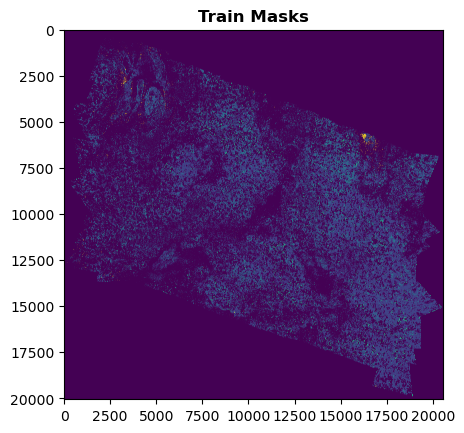

<Axes: title={'center': 'Train Masks'}>

In [7]:
show(masked_train_masks, cmap="viridis", title="Train Masks")

In [ ]:
# geoai.view_raster(test_raster_url)

## Create training data

In [9]:
out_folder = "output"

In [11]:
tiles = geoai.export_geotiff_tiles(
    in_raster=train_raster_gccmasked_path,
    out_folder=out_folder,
    in_class_data=train_masks_gccmasked_path,
    tile_size=512,
    stride=128,
    buffer_radius=0,
)

Detected in_class_data as raster: /data/shunan/data/KU/AbiskoStudent/Classified_map_22_07_07_gccmasked.tif
Raster CRS: EPSG:32634
Raster dimensions: 20558 x 20049

Raster info for /data/shunan/data/KU/AbiskoStudent/22_07_07_orthomosaic_georef_processed_gccmasked.tif:
  CRS: EPSG:32634
  Dimensions: 20558 x 20049
  Resolution: (0.02421902849331363, 0.02421902849331363)
  Bands: 5
  Bounds: BoundingBox(left=419417.857330099, bottom=7582743.279618582, right=419915.7521178645, top=7583228.846920844)
Found 6 unique classes in raster: [ 1  2  3  4  6 10]


Generated: 24332, With features: 15917: 100%|██████████| 24332/24332 [18:50<00:00, 21.53it/s]



------- Export Summary -------
Total tiles exported: 24332
Tiles with features: 15917 (65.4%)
Average feature pixels per tile: 173093.9
Output saved to: output

------- Georeference Verification -------


## Train object detection model

In [ ]:
geoai.train_MaskRCNN_model(
    images_dir=f"{out_folder}/images",
    labels_dir=f"{out_folder}/labels",
    output_dir=f"{out_folder}/models",
    num_channels=5,
    pretrained=True,
    batch_size=4,
    num_epochs=10,
    learning_rate=0.005,
    val_split=0.2,
)

Using device: cpu
Found 24332 image files and 24332 label files
Training on 19465 images, validating on 4867 images


Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /home/shunan/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth
100%|██████████| 170M/170M [00:01<00:00, 103MB/s]  


## Run inference

In [ ]:
masks_path = "naip_water_prediction.tif"
model_path = f"{out_folder}/models/best_model.pth"

In [ ]:
geoai.object_detection(
    test_raster_path,
    masks_path,
    model_path,
    window_size=512,
    overlap=128,
    confidence_threshold=0.3,
    batch_size=4,
    num_channels=5,
)

## Vectorize masks

In [ ]:
output_path = "species_maskrcnn.geojson"
gdf = geoai.raster_to_vector(
    masks_path, output_path, min_area=1000, simplify_tolerance=1
)

In [ ]:
gdf = geoai.add_geometric_properties(gdf)

In [ ]:
len(gdf)

In [ ]:
geoai.view_vector_interactive(gdf, tiles=test_raster_gccmasked_path)

In [ ]:
gdf["elongation"].hist()

In [ ]:
gdf_filtered = gdf[gdf["elongation"] < 10]

In [ ]:
len(gdf_filtered)

## Visualize results

In [ ]:
geoai.view_vector_interactive(gdf_filtered, tiles=test_raster_gccmasked_path)

In [ ]:
geoai.create_split_map(
    left_layer=gdf_filtered,
    right_layer=test_raster_gccmasked_path,
    left_args={"style": {"color": "red", "fillOpacity": 0.2}},
    basemap=test_raster_gccmasked_path,
)

![image](https://github.com/user-attachments/assets/a269b5a0-9f72-4ed8-8b2d-a175bbc45a23)